# Fine-tuning the LLaMA model

This notebook provides a step-by-step guide to fine-tuning the **LLaMA 3.2 3B model** ([meta-llama/Llama-3.2-3B](https://huggingface.co/meta-llama/Llama-3.2-3B)) as part of our experimentation process. 

The model is fine-tuned for **3 epochs** using a **learning rate of 1e-6** and a **batch size of 32**.


Users can follow the fine-tuning process interactively within the notebook. Alternatively, if you prefer to execute the full pipeline automatically, you can run the following scripts via terminal:

**For model fine-tuning**:
```bash
python finetune_model.py --model llama
```

**For elaboration generation:**

```bash
python generate_elaborations.py --model llama-ft
```
This assumes that the required model and dataset are correctly placed in their respective directories.

# Load the data

In [1]:
from dataset_utils import load_dataset_from_csv

ds_type = "c2s"
setting = "target-phrase"

dataset = load_dataset_from_csv(ds_type, setting)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['doc_num', 'source_text', 'label_text', 'elaboration_sentence', 'contextual_specificity_rating', 'target_sentence_target'],
        num_rows: 1046
    })
    validation: Dataset({
        features: ['doc_num', 'source_text', 'label_text', 'elaboration_sentence', 'contextual_specificity_rating', 'target_sentence_target'],
        num_rows: 132
    })
    test: Dataset({
        features: ['doc_num', 'source_text', 'label_text', 'elaboration_sentence', 'contextual_specificity_rating', 'target_sentence_target'],
        num_rows: 116
    })
})


# Load the model

In [1]:
import torch

if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Number of GPUs available: {num_gpus}")
else:
    print("CUDA is not available. No GPUs detected.")

Number of GPUs available: 1


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from trl import setup_chat_format
from trl.extras.dataset_formatting import conversations_formatting_function
from accelerate import PartialState

torch.cuda.empty_cache()

device_map = "auto" # for 2 or more GPUs
# LLAMA 3.2 3B
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.2-3B', cache_dir="../models/llama/") 
model =  AutoModelForCausalLM.from_pretrained('meta-llama/Llama-3.2-3B', cache_dir="../models/llama/",device_map={'':torch.cuda.current_device()})

In [3]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token 

# Prompt Design

In [3]:
ZERO_SHOT_SYSTEM_PROMPT = """You are an expert in generating exactly one short explanatory sentence (made up of around 10 words or fewer) in a plain English for a given context text. 
Your task is to provide additional information related to the complex statement, term, action, or concept that is semantically missing from the context text.
You may do this by offering a definition, examples, background knowledge, general statements, a description of the flow of actions, or an explanation of the reason or result of the target action.
The tone should be plain and simple!
Return only ONE short concise explanatory sentence!
"""

In [3]:
# text with elaboration sentence masked -> elaboration sentence
SYSTEM_PROMPT_MASKED = """You are an expert in generating exactly one short explanatory sentence (made up of around 10 words or fewer) in a plain English for a given context text. 
Your task is to provide additional information related to the complex statement, term, action, or concept that is semantically missing from the context text.
You may do this by offering a definition, examples, background knowledge, general statements, a description of the flow of actions, or an explanation of the reason or result of the target action.
Your task is to replace the `<explanatory sentence>` tag in the provided text with the explanation sentence you generate.
Return only the explanation sentence itself, without any tags, formatting, or additional text.
The tone should be plain and simple!
Return only ONE short concise explanatory sentence!
"""

In [3]:
# text with elaboration sentence masked -> text with filled-out elaboration sentence
SYSTEM_PROMPT_MASKED2 = """You are an expert in generating exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. 
Your task is to replace the `<explanatory sentence>` tag in the provided text with an explanation sentence that adds relevant information to clarify a complex statement, term, action, or concept that is semantically missing from the text.
The tone should be plain and simple!
"""

In [5]:
SYSTEM_PROMPT_SHORT = """You are an expert in generating exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. 
The tone should be plain and simple!"""

## Alpaca format

#### BASE

In [3]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""
base_prompt_v2 = """### User: You are an expert in providing additional context. Your task is to generate exactly ONE short, concise sentence (made up of around 10 words or fewer) in plain English to provide additional context to complex term or concept in a given text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message(context):
    return f"Return the explanation sentence for the following context text: '{context}'."

def formatting_prompts_func(examples):
    contexts = examples["source_text"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, elab_sent in zip(contexts, elab_sentences):
        text = alpaca_prompt.format(create_user_message(context), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. 
The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["source_text"]
    texts = []
    for context in contexts:
        text = test_alpaca_prompt.format(create_user_message(context)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

In [4]:
print(formatted_test_dataset[11])

### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. 
The tone should be plain and simple! Return the explanation sentence for the following context text: 'CEOs of other companies involved in the effort haven't been widely quoted on the project. Similarly, when Zuckerberg launched the advocacy group FWD.us earlier this year to lobby for immigration reform, including policies that help the tech industry, he announced it in a first-person essay in the Washington Post. Although a number of prominent tech executives and venture capitalists signed on to the FWD.us organization, it's widely viewed as Zuckerberg's group.'.
### Assistant:


#### Masked version

In [3]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message(context):
    return f"Return the explanation sentence that could replace the `<explanatory sentence>` tag in the following text: '{context}'."

def formatting_prompts_func(examples):
    contexts = examples["source_text"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, elab_sent in zip(contexts, elab_sentences):
        text = alpaca_prompt.format(create_user_message(context), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. 
The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["source_text"]
    texts = []
    for context in contexts:
        text = test_alpaca_prompt.format(create_user_message(context)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

In [4]:
formatted_test_dataset[0]

"### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. \nThe tone should be plain and simple! Return the explanation sentence that could replace the `<explanatory sentence>` tag in the following text: 'New companies have come that need skilled workers with more education. New Haven youth want those jobs, but they do not have the education or the skills. <explanatory sentence>'.\n### Assistant:"

#### Specifying the subject

In [4]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message_subject(context, subject):
    return f"Return the explanation sentence for the following context text: '{context}'. The explanation sentence should refer to the {subject}."
print(tokenizer.eos_token )

def formatting_prompts_func(examples):
    contexts = examples["source_text"]
    subjects = examples["subject"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, subject, elab_sent in zip(contexts, subjects, elab_sentences):
        text = alpaca_prompt.format(create_user_message_subject(context, subject), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. 
The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["source_text"]
    subjects = examples["subject"]
    texts = []
    for context, subject in zip(contexts, subjects):
        text = test_alpaca_prompt.format(create_user_message_subject(context, subject)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

<|end_of_text|>


In [5]:
formatted_test_dataset[11]

"### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. \nThe tone should be plain and simple! Return the explanation sentence for the following context text: 'At a time when Facebook's growth rate is slowing in the developed world, Zuckerberg has acknowledged Facebook stands to benefit from putting the Internet within reach of more people around the world. An ambitious effort to bring the Internet to billions of poor people is only the latest move by Facebook Inc.'s Mark Zuckerberg to carve out a high-profile role as a tech CEO who can wield influence over public issues. And while he's not the only one of his peers promoting the power of technology to change the world, the scale and ambition of Zuckerberg's industry alliance to promote global Internet access makes the 29-year-old CEO one of the most prominent advocates for Silicon Valley's unique blend of business and altruism

#### Specifying the target phrase

In [3]:
# set the pad_token for llama 3.2 3B
from prompt_utils import base_prompt_zeroshot_train, base_prompt_zeroshot_test, create_user_message
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message_target(context, target):
    return f"Return the explanation sentence for the following context text: '{context}'. The explanation sentence should clarify the {target}."

def formatting_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_target"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, target, elab_sent in zip(contexts, targets, elab_sentences):
        text = base_prompt_zeroshot_train.format(create_user_message(context,"target-phrase",target), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. 
The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_target"]
    texts = []
    for context, target in zip(contexts, targets):
        text = base_prompt_zeroshot_test.format(create_user_message(context, "target-phrase",target)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

In [13]:
formatted_test_dataset[1]

"### User: You are an expert in clarifying unclear, complex term or concept in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! Return the explanation sentence for the following context text: 'But the death toll could have been higher. Forecasters said more people could have died if there were no river gauges.'. The explanation sentence should specifically clarify the target_phrase='river gauges'.\n### Assistant:"

In [5]:
formatting_prompts_func(dataset["train"])[0]

"### User: You are an expert in clarifying unclear, complex term or concept in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! Return the explanation sentence for the following context text: 'A watermark is an image that can be seen in the paper when you hold it up to the light. Investigators say Kellogg tried to copy the watermark.'. The explanation sentence should specifically clarify the target_phrase='tried to copy the watermark'.\n### Assistant: Here's how they say he did it.<|end_of_text|>"

#### Specifying the target sentence for clarification

In [5]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message_target(context, target):
    return f"Return the explanation sentence for the following context text: '{context}'. The explanation sentence should specifically clarify the target_sentence={target}"
print(tokenizer.eos_token )

def formatting_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_4o"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, target, elab_sent in zip(contexts, targets, elab_sentences):
        text = alpaca_prompt.format(create_user_message_target(context, target), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. 
The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_4o"]
    texts = []
    for context, target in zip(contexts, targets):
        # must add EOS_TOKEN, otherwise the generation wont stop
        text = test_alpaca_prompt.format(create_user_message_target(context, target)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

<|end_of_text|>


In [6]:
print(formatted_test_dataset[10])

### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. 
The tone should be plain and simple! Return the explanation sentence for the following context text: 'Snowden is accused of leaking information about government surveillance programs and has been charged with espionage. He fled to Hong Kong and then Russia, where he remained at the Moscow airport for than a month before Russia granted him asylum last week. Moscow has accused the United States of installing a missile shield in Eastern Europe as a deterrent against Russia.'. The explanation sentence should specifically clarify the target_sentence=Moscow has accused the United States of installing a missile shield in Eastern Europe as a deterrent against Russia.
### Assistant:


#### Specifying both the target phrase/ subject and the target sentence

In [3]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message_target(context, target,target_sentence):
    return f"Return the explanation sentence for the following context text: '{context}'. The explanation sentence should specifically clarify the target_sentence={target_sentence} by referring to the {target}."
print(tokenizer.eos_token )

def formatting_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_target"] # subject 
    target_sents = examples["target_sentence_4o"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, target, target_sent, elab_sent in zip(contexts, targets, target_sents, elab_sentences):
        text = alpaca_prompt.format(create_user_message_target(context, target, target_sent), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_target"] # subject
    target_sents = examples["target_sentence_4o"]
    texts = []
    for context, target, target_sent in zip(contexts, targets, target_sents):
        text = test_alpaca_prompt.format(create_user_message_target(context, target, target_sent)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

<|end_of_text|>


In [4]:
formatted_test_dataset[19]

"### User: You are an expert in clarifying unclear or complex terms and concepts in a given text. Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! Return the explanation sentence for the following context text: 'By her early 30s, she had become depressed and said she could barely write a full sentence. Her good fortune was to open a bookstore with her husband, in 1963. Her narrative talents resurfaced but her marriage collapsed.'. The explanation sentence should specifically clarify the target_sentence=Her narrative talents resurfaced but her marriage collapsed. by referring to the target_phrase='traditional roles'.\n### Assistant:"

#### Specifying both the target phrase (from the target sentence) and the target sentence

In [5]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message_target(context, target, target_sentence):
    return f"Return the explanation sentence for the following context text: '{context}'. The explanation sentence should specifically clarify the {target_sentence} by referring to the {target}."
print(tokenizer.eos_token )

def formatting_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_target"]
    target_sents = examples["target_sentence_4o"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, target, target_sent, elab_sent in zip(contexts, targets, target_sents, elab_sentences):
        text = alpaca_prompt.format(create_user_message_target(context, target, target_sent), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["source_text"]
    targets = examples["target_sentence_target"]
    target_sents = examples["target_sentence_4o"]
    texts = []
    for context, target, target_sent in zip(contexts, targets, target_sents):
        text = test_alpaca_prompt.format(create_user_message_target(context, target, target_sent)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

<|end_of_text|>


In [9]:
formatted_test_dataset[0]

"### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. The tone should be plain and simple! Return the explanation sentence for the following context text: 'New companies have come that need skilled workers with more education. New Haven youth want those jobs, but they do not have the education or the skills.'. The explanation sentence should specifically clarify the target_sentence='New Haven youth want those jobs, but they do not have the education or the skills.' by referring to the target_phrase='do not have the education or the skills'.\n### Assistant:"

#### Target sentence -> elaboration

In [5]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message(context):
    return f"Return the clarification sentence for the {context}."

def formatting_prompts_func(examples):
    contexts = examples["target_sentence_4o"]
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, elab_sent in zip(contexts, elab_sentences):
        # must add EOS_TOKEN, otherwise the generation wont stop
        text = alpaca_prompt.format(create_user_message(context), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: Your task is to generate exactly ONE short concise clarification sentence (made up of around 10 words or fewer) in plain English for a given sentence. 
The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["target_sentence_4o"]
    texts = []
    for context in contexts:
        # must add EOS_TOKEN, otherwise the generation wont stop
        text = test_alpaca_prompt.format(create_user_message(context)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

In [6]:
formatted_test_dataset[0]

"### User: Your task is to generate exactly ONE short concise clarification sentence (made up of around 10 words or fewer) in plain English for a given sentence. \nThe tone should be plain and simple! Return the clarification sentence for the 'It will make a difference by paying for college.' .\n### Assistant:"

#### Target sentence + target phrase/subject -> elaboration

In [6]:
# set the pad_token for llama 3.2 3B
tokenizer.pad_token = tokenizer.eos_token
EOS_TOKEN = tokenizer.eos_token

alpaca_prompt = """### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. The tone should be plain and simple! {}\n### Assistant: {}"""

def create_user_message(context, target):
    return f"Return the clarification sentence for the {context}. The explanation sentence should refer to the {target}." 

def formatting_prompts_func(examples):
    contexts = examples["target_sentence_4o"]
    targets = examples["target_sentence_target"] # subject
    elab_sentences = examples["elaboration_sentence"]
    texts = []
    for context, target, elab_sent in zip(contexts, targets, elab_sentences):
        text = alpaca_prompt.format(create_user_message(context, target), elab_sent) + EOS_TOKEN
        texts.append(text)
    return texts

test_alpaca_prompt = """### User: Your task is to generate exactly ONE short concise clarification sentence (made up of around 10 words or fewer) in a plain English for a given sentence. 
The tone should be plain and simple! {}\n### Assistant:"""

def formatting_test_prompts_func(examples):
    contexts = examples["target_sentence_4o"]
    targets = examples["target_sentence_target"] # subject
    texts = []
    for context, target in zip(contexts,targets):
        text = test_alpaca_prompt.format(create_user_message(context, target)) 
        texts.append(text)
    return texts

formatted_test_dataset = formatting_test_prompts_func(dataset["test"])

In [7]:
formatted_test_dataset[0]

"### User: Your task is to generate exactly ONE short concise clarification sentence (made up of around 10 words or fewer) in a plain English for a given sentence. \nThe tone should be plain and simple! Return the clarification sentence for the target_sentence='New Haven needs to invest in educating its youth so they will be qualified to do those high-skilled jobs when they become adults.'. The explanation sentence should refer to the target_phrase='educating its youth'.\n### Assistant:"

# Fine-tune

https://huggingface.co/docs/trl/en/sft_trainer

In [ ]:
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM
from transformers import DataCollatorForLanguageModeling

import os 
# disable parallelism warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"


model.train()

# data collator -> alpaca
data_collator = DataCollatorForCompletionOnlyLM(
    tokenizer=tokenizer, 
    mlm=False,
    response_template="### Assistant:"
)

output_name = f"{ds_type}-{setting}"
print(output_name)

training_args = SFTConfig(
    output_dir=f"../models/llama/llama-news-ft/results/results-llama-alpaca-{output_name}",
    max_seq_length=250, 
    eval_strategy="epoch",  
    save_strategy="epoch",  
    logging_strategy="steps",  
    logging_steps=6, 
    learning_rate=1e-6,  
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=32,  
    num_train_epochs=3,  
    weight_decay=0.01,  
    warmup_steps=2,    
    optim="paged_adamw_8bit",  
    fp16=True,  
    logging_dir=f"../models/llama/llama-news-ft/logs/logs-llama-alapaca-{output_name}", 
    push_to_hub=False,
    group_by_length=True,  
    save_total_limit=1,#1,
    packing=False,
    load_best_model_at_end=True, 
    greater_is_better=False,
    metric_for_best_model="eval_loss"

)


trainer = SFTTrainer(
    model,
    train_dataset=dataset["train"], 
    eval_dataset=dataset["validation"], 
    args=training_args,   
    formatting_func= formatting_prompts_func, 
    data_collator=data_collator, 
)

model.config.use_cache = False

In [ ]:
trainer.train()

## Learning curve

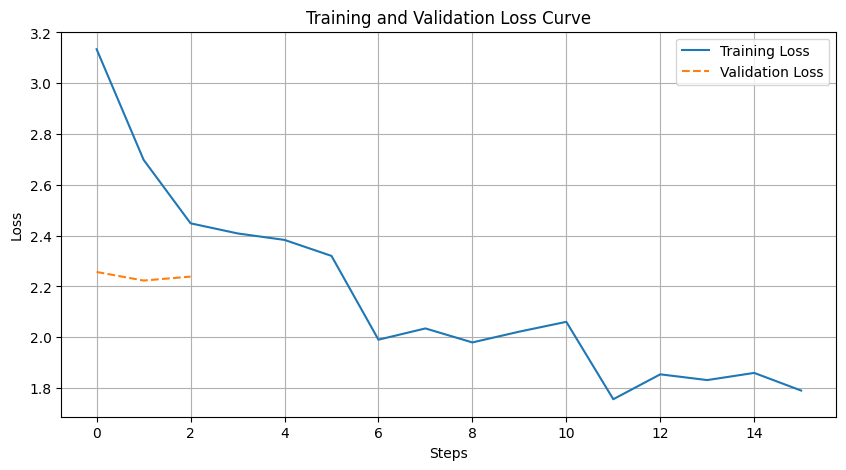

In [6]:
from model_utils import plot_loss_curves
plot_loss_curves(trainer)

## Save the model

In [40]:
trainer.save_model("../models/llama/llama-news-ft/llama-c2s-masked-label-text-out")

## Clean-up

In [18]:
from model_utils import clear_directory
import torch

torch.cuda.empty_cache()
del model, trainer, tokenizer, data_collator
clear_directory(logs_dir)

Directory does not exist: ../models/llama3.2-news-ft/logs/logs-c2osp


# Generate predictions

https://github.com/NielsRogge/Transformers-Tutorials/blob/master/Mistral/Supervised_fine_tuning_(SFT)_of_an_LLM_using_Hugging_Face_tooling.ipynb

## Load saved model

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

saved_model = AutoModelForCausalLM.from_pretrained("../models/llama/llama-news-ft/results/results-llama-alpaca-c4spo-target-sent-target/checkpoint-66")
saved_tokenizer = AutoTokenizer.from_pretrained("../models/llama/llama-news-ft/results/results-llama-alpaca-c4spo-target-sent-target/checkpoint-66")

In [19]:
import os 
# disable parallelism warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"
model = saved_model
tokenizer = saved_tokenizer

In [8]:
model, tokenizer = setup_chat_format(model, tokenizer)
formatting_func = conversations_formatting_function(tokenizer, "messages")

## Example

In [7]:
from transformers import pipeline, StoppingCriteria, StoppingCriteriaList
import torch

class RefinedEndSentenceStoppingCriteria(StoppingCriteria):
    def __init__(self, tokenizer, sentence_end_tokens):
        super().__init__()
        self.tokenizer = tokenizer
        self.sentence_end_token_ids = [
            self.tokenizer.convert_tokens_to_ids(token) for token in sentence_end_tokens
        ]
        # include eos_token_id
        self.eos_token_id = tokenizer.eos_token_id  

    def is_valid_stop(self, input_ids):
        # get the last token and the one before it
        if len(input_ids[0]) < 2:
            return False  # Not enough tokens to decide
        last_token_id = input_ids[0, -1].item()
        second_last_token_id = input_ids[0, -2].item()

        # decode tokens to check context
        last_token = self.tokenizer.decode([last_token_id])
        second_last_token = self.tokenizer.decode([second_last_token_id])

        # stop if it's a sentence-ending token and not part of an abbreviation
        if (
            last_token in [".", "!", "?"]  # check if it's a sentence-ending token
            and len(second_last_token) > 1  # check if not part of an abbreviation
            and not second_last_token.isupper()  # check if it's not "U.S." or similar
        ):
            return True

        # include end-of-sequence token
        return last_token_id == self.eos_token_id

    def __call__(self, input_ids, scores, **kwargs):
        return self.is_valid_stop(input_ids)


sentence_end_tokens = [".","\n","!", "?"]
stopping_criteria = StoppingCriteriaList([RefinedEndSentenceStoppingCriteria(tokenizer, sentence_end_tokens)])

In [8]:
import torch
import random 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

example = random.choice(formatted_test_dataset)

inputs = tokenizer(
    example, # input_text,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=512  
).to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=32,  
        min_length=10,
        do_sample=False,  
        temperature=None,  
        top_p=None,  
        num_return_sequences=1,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
        stopping_criteria=stopping_criteria
    )

generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(generated_text)
response = extract_response(generated_text)
print("Extracted Response:", response)

### User: Your task is to generate exactly ONE short concise explanation sentence (made up of around 10 words or fewer) in a plain English for a given context text. 
The tone should be plain and simple! Return the explanation sentence for the following context text: 'Brown was a black teenager without a weapon who was shot by a white police officer. He was killed in August in Ferguson, Missouri, near St. Louis. The shooting set off nearly nightly protests and violence. The black community felt that Brown wouldn't have been killed if he was white.'.
### Assistant: The officer was not charged with a crime.
Extracted Response: The officer was not charged with a crime.


## Generate predictions

In [ ]:
from tqdm.notebook import tqdm
from accelerate import infer_auto_device_map, init_empty_weights, load_checkpoint_and_dispatch
from dataset_utils import create_results_df

import pandas as pd

def extract_response(text, prefix = "### Assistant:"):
    if prefix in text:
        return text.split(prefix, 1)[1].strip()
    return None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
model.config.use_cache = True


search_type = {"beam-search":{"num_beams":4, "early_stopping":True, 
                              "filename":f"../data/gen_predictions/predictions_llama-ft-{output_name}.csv"},
              "greedy":{"num_beams":1, "early_stopping":False,
                        "filename":f"../data/gen_predictions/predictions_llama-ft-{output_name}-greedy.csv"}
}

for search_t in search_type.keys():
    
    df_results = create_results_df(dataset)
    
    for idx, row in tqdm(df_results.iterrows(),total=len(df_results)):
        if row["pred_elaboration"]=="":
            # chatML format -> input_text = formatting_func(formatted_test_dataset[idx])
            inputs = tokenizer(
                formatted_test_dataset[idx], # input_text
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=512 
            ).to(device) 
            
            with torch.no_grad():
                output_ids = model.generate(
                    input_ids=inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    max_new_tokens=32,  
                    min_length=10,
                    do_sample=False, 
                    temperature=None,  
                    top_p=None,
                    num_beams = search_type[search_t]["num_beams"], 
                    early_stopping = search_type[search_t]["early_stopping"], 
                    num_return_sequences=1,
                    no_repeat_ngram_size=3,
                    eos_token_id=tokenizer.eos_token_id,
                    pad_token_id=tokenizer.eos_token_id,
                    stopping_criteria=stopping_criteria
                )
            
            generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
            response = extract_response(generated_text)
            df_results.at[idx,"pred_elaboration"] = response
    
    df_results.to_csv(search_type[search_t]["filename"], index=False)
    print("Saved ", search_type[search_t]["filename"])